In [29]:
import pandas as pd

df = pd.read_csv('final_data.csv')

In [30]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,EngagementScore,TenureGroup,SpendingLevel,ChargesRatio,ServicesCount,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,0.0,0.0,0.967585,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,1936.30,1.0,1.0,32.605695,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,107.70,0.0,1.0,1.971741,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,1903.50,2.0,0.0,42.511547,0,0,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,141.40,0.0,1.0,2.115063,0,1,0,0,1,0


In [31]:
X = df.drop('Churn', axis=1)   # كل الـ features
y = df['Churn']                # target

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Best K: 2


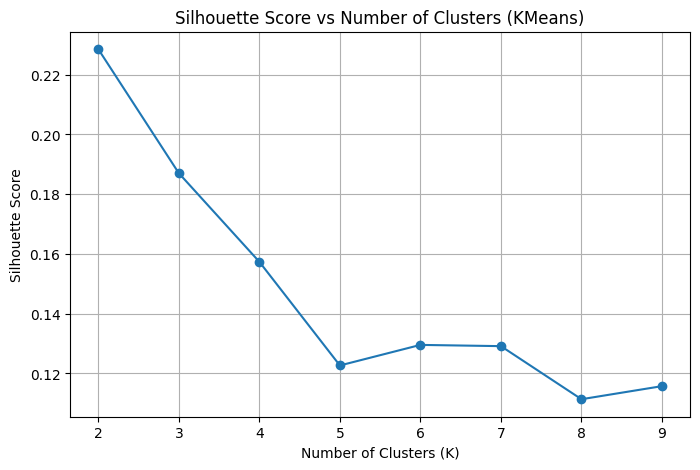

In [33]:
# silhotte score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []

K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

best_k = K_range[sil_scores.index(max(sil_scores))]
print("Best K:", best_k)

plt.figure(figsize=(8,5))
plt.plot(list(K_range), sil_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters (KMeans)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

In [34]:
#kmeans
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_score = silhouette_score(X_scaled, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.22854606890746185


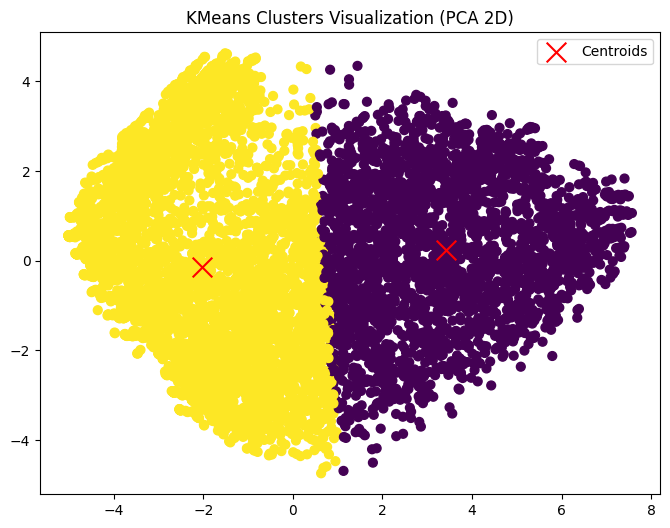

In [35]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis', s=40)

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c='red', marker='x', s=200, label='Centroids')

plt.title("KMeans Clusters Visualization (PCA 2D)")
plt.legend()
plt.show()

In [36]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
gmm_score = silhouette_score(X_scaled, gmm_labels)
print("GMM Silhouette Score:", gmm_score)

GMM Silhouette Score: 0.13529263080920728


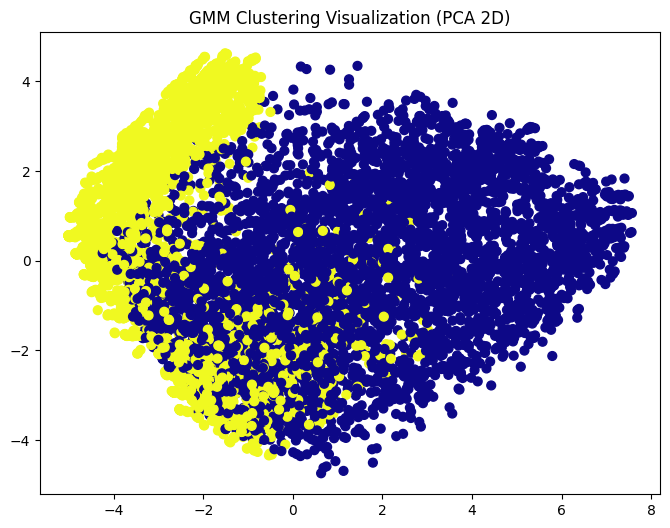

In [37]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels, cmap='plasma', s=40)

plt.title("GMM Clustering Visualization (PCA 2D)")
plt.show()

In [38]:
df['KMeans_Cluster'] = kmeans_labels
df['GMM_Cluster'] = gmm_labels

In [39]:
print("KMeans Score:", kmeans_score)
print("GMM Score:", gmm_score)

KMeans Score: 0.22854606890746185
GMM Score: 0.13529263080920728


In [40]:
from sklearn.cluster import DBSCAN
# initial trial:
dbscan = DBSCAN(eps=0.5, min_samples=5)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("Unique DBSCAN labels:", set(dbscan_labels))

Unique DBSCAN labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int6

In [41]:
# outliers (label = -1):
outliers = df[df['DBSCAN_Cluster'] == -1]
normal_points = df[df['DBSCAN_Cluster'] != -1]

print("num of outliers:", len(outliers))
print("num of normal customers", len(normal_points))

num of outliers: 6027
num of normal customers 984


In [42]:
# Outliers
outlier_churn = outliers['Churn'].value_counts(normalize=True)
# Normal
normal_churn = normal_points['Churn'].value_counts(normalize=True)

comparison = pd.DataFrame({
    'Outliers': outlier_churn,
    'Normal Customers': normal_churn
})

print(comparison)

       Outliers  Normal Customers
Churn                            
0      0.730048          0.757114
1      0.269952          0.242886


In [43]:
comparison = pd.DataFrame({
    'Outliers': outlier_churn,
    'Normal Customers': normal_churn
})

print(comparison)

       Outliers  Normal Customers
Churn                            
0      0.730048          0.757114
1      0.269952          0.242886


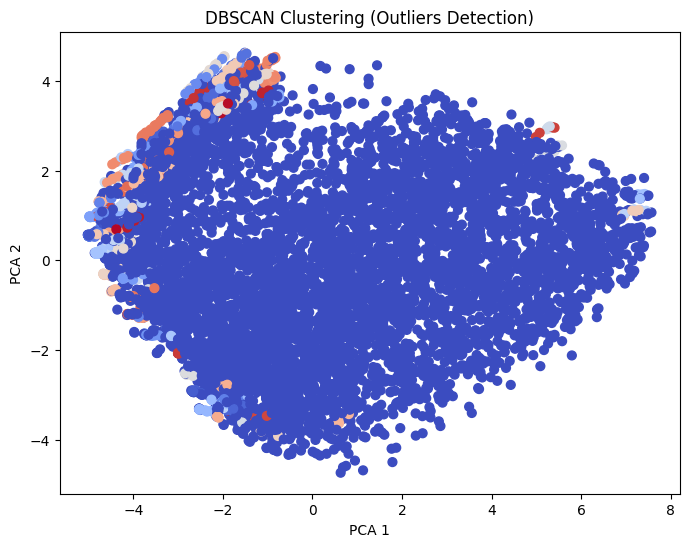

In [44]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_labels,
    cmap='coolwarm',
    s=40
)

plt.title("DBSCAN Clustering (Outliers Detection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [45]:
print("Description of Outliers:")
print(outliers.describe())

Description of Outliers:
            gender  SeniorCitizen      Partner   Dependents       tenure  \
count  6027.000000    6027.000000  6027.000000  6027.000000  6027.000000   
mean      0.502572       0.184337     0.507218     0.297495    34.120292   
std       0.500035       0.387791     0.499989     0.457194    23.896571   
min       0.000000       0.000000     0.000000     0.000000     1.000000   
25%       0.000000       0.000000     0.000000     0.000000    12.000000   
50%       1.000000       0.000000     1.000000     0.000000    32.000000   
75%       1.000000       0.000000     1.000000     1.000000    56.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  MultipleLines  OnlineSecurity  OnlineBackup  \
count   6027.000000    6027.000000     6027.000000   6027.000000   
mean       0.888336       0.460760        0.327360      0.394890   
std        0.314979       0.498499        0.469289      0.488868   
min        0.00000

In [46]:
print("\nDescription of normal customers:")
print(normal_points.describe())


Description of normal customers:
           gender  SeniorCitizen     Partner  Dependents      tenure  \
count  984.000000     984.000000  984.000000  984.000000  984.000000   
mean     0.522358       0.027439    0.333333    0.305894   21.868902   
std      0.499754       0.163442    0.471644    0.461019   25.867062   
min      0.000000       0.000000    0.000000    0.000000    1.000000   
25%      0.000000       0.000000    0.000000    0.000000    1.000000   
50%      1.000000       0.000000    0.000000    0.000000    7.500000   
75%      1.000000       0.000000    1.000000    1.000000   45.000000   
max      1.000000       1.000000    1.000000    1.000000   72.000000   

       PhoneService  MultipleLines  OnlineSecurity  OnlineBackup  \
count    984.000000     984.000000      984.000000    984.000000   
mean       0.994919       0.180894        0.034553      0.034553   
std        0.071138       0.385126        0.182737      0.182737   
min        0.000000       0.000000        0.0

In [47]:
df['Is_Outlier'] = df['DBSCAN_Cluster'] == -1
pd.crosstab(df['Is_Outlier'], df['Churn'], normalize='index')

Churn,0,1
Is_Outlier,,
False,0.757114,0.242886
True,0.730048,0.269952
